In [6]:
import pandas as pd
import numpy as np

from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as ec
from selenium.webdriver.chrome.options import Options
from datetime import datetime, timedelta
# from oceanoobsbrasil.db import GetData
# from oceanoobsbrasil.utils import *
from oceanobs.buoys.aqualink import AqualinkBuoy
from oceanobs.buoys.simcosta import Simcosta
from oceanobs.oceanobs_handler.db_handler import DbHandler
from oceanobs.oceanobs_handler.oceanobs_handler import OceanobsHandler
from oceanobs.observational_data.rico_surf import RicoSurf
from oceanobs.buoys.pnboia import Pnboia
from oceanobs.observational_data.wave_check import WaveCheck
import os
from dotenv import load_dotenv
import requests
from bs4 import BeautifulSoup
import re
import chromedriver_binary
import time
from oceanobs.oceanobs import Oceanobs
import xarray as xr
from io import BytesIO
from netCDF4 import Dataset
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from oceanobs.remote_sensing.scatterometer import Scatterometer

In [10]:
lat_lon_limits = {'min_lat': -36, 'max_lat': 8, 'min_lon': -50, 'max_lon': -20}
start_date = "2025-03-30T00:00:00"
a = Scatterometer(lat_lon_limits=lat_lon_limits,start_date=start_date, n_workers=1)

In [11]:
data = a.get()

 [ Processing: 100% ] |###################################################| [|]


/tmp/tmpfns5v7yi/97600499_ascat_20250329_225400_metopb_65015_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmpfns5v7yi/97600500_ascat_20250330_090000_metopb_65021_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmpfns5v7yi/97600501_ascat_20250330_104200_metopb_65022_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmpfns5v7yi/97600502_ascat_20250330_205100_metopb_65028_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmpfns5v7yi/97600503_ascat_20250330_223300_metopb_65029_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmpfns5v7yi/97600504_ascat_20250331_084200_metopb_65035_eps_o_250_3301_ovw.l2_subsetted.nc4


In [13]:
data

,date_time,latitude,longitude,wdir,wspd,geometry,station_type
34,2025-03-30 00:21:20,-35.965111,148.298645,215.000000,18.100000,POINT (16508529.649 -4295821.73),Scatterometer
66,2025-03-30 00:21:20,-35.978828,147.421600,209.399994,17.799999,POINT (16410897.482 -4297708.588),Scatterometer
67,2025-03-30 00:21:20,-35.904240,147.683014,211.500000,18.000000,POINT (16439997.908 -4287452.884),Scatterometer
68,2025-03-30 00:21:20,-35.829079,147.943970,214.399994,18.299999,POINT (16469047.376 -4277128.276),Scatterometer
69,2025-03-30 00:21:20,-35.753349,148.204407,216.899994,18.600000,POINT (16498039.091 -4266735.476),Scatterometer
...,...,...,...,...,...,...,...
32793,2025-03-31 09:40:16,-35.653198,156.540649,235.800003,23.100000,POINT (17426025.381 -4253006.315),Scatterometer
32794,2025-03-31 09:40:16,-35.577702,156.280670,235.100006,23.100000,POINT (17397084.624 -4242668.266),Scatterometer
32806,2025-03-31 09:40:16,-35.940529,156.708496,233.800003,23.700001,POINT (17444709.988 -4292441.319),Scatterometer
32807,2025-03-31 09:40:16,-35.865349,156.447449,235.300003,23.500000,POINT (17415650.329 -4282109.359),Scatterometer


In [11]:
x = data.date_time[data.date_time.notna()]

In [13]:
data.

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
32160   NaN
32161   NaN
32162   NaN
32163   NaN
32164   NaN
Name: flag, Length: 32165, dtype: float64

In [6]:
df = pd.DataFrame(data).T

In [8]:
df.count()

0    25214
1    25214
2    25214
3    18203
4    18203
5    25214
dtype: int64

In [17]:
ds = xr.open_dataset("/tmp/tmplmn949vi/97582495_ascat_20250330_223300_metopb_65029_eps_o_250_3301_ovw.l2_subsetted.nc4")
ds

<xarray.Dataset> Size: 515kB
Dimensions:           (NUMROWS: 219, NUMCELLS: 42)
Coordinates:
    lat               (NUMROWS, NUMCELLS) float32 37kB ...
    lon               (NUMROWS, NUMCELLS) float32 37kB ...
Dimensions without coordinates: NUMROWS, NUMCELLS
Data variables:
    time              (NUMROWS, NUMCELLS) datetime64[ns] 74kB ...
    wvc_index         (NUMROWS, NUMCELLS) float32 37kB ...
    model_speed       (NUMROWS, NUMCELLS) float32 37kB ...
    model_dir         (NUMROWS, NUMCELLS) float32 37kB ...
    ice_prob          (NUMROWS, NUMCELLS) float32 37kB ...
    ice_age           (NUMROWS, NUMCELLS) float32 37kB ...
    wvc_quality_flag  (NUMROWS, NUMCELLS) float64 74kB ...
    wind_speed        (NUMROWS, NUMCELLS) float32 37kB ...
    wind_dir          (NUMROWS, NUMCELLS) float32 37kB ...
    bs_distance       (NUMROWS, NUMCELLS) float32 37kB ...
Attributes: (12/30)
    title:                            MetOp-B ASCAT Level 2 25.0 km Ocean Sur...
    title_short_name:                 ASCATB-L2-25km
    Conventions:                      CF-1.6
    institution:                      EUMETSAT/OSI SAF/KNMI
    source:                           MetOp-B ASCAT
    software_identification_level_1:  1105
    ...                               ...
    history:                          N/A\n2025-03-31 10:17:36.354173 l2ss-py...
    references:                       ASCAT Wind Product User Manual, https:/...
    comment:                          Orbit period and inclination are consta...
    creation_date:                    2025-03-31
    creation_time:                    00:59:14
    history_json:                     [{"date_time": "2025-03-31T10:17:36.354...

In [16]:
data = a.get()

 [ Processing: 100% ] |###################################################| [|]


/tmp/tmplmn949vi/97582487_ascat_20250328_231500_metopb_65001_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582488_ascat_20250329_092100_metopb_65007_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582489_ascat_20250329_110300_metopb_65008_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582490_ascat_20250329_211200_metopb_65014_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582491_ascat_20250329_225400_metopb_65015_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582492_ascat_20250330_090000_metopb_65021_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582493_ascat_20250330_104200_metopb_65022_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582494_ascat_20250330_205100_metopb_65028_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582495_ascat_20250330_223300_metopb_65029_eps_o_250_3301_ovw.l2_subsetted.nc4
/tmp/tmplmn949vi/97582496_ascat_20250331_070000_metopb_65034_eps_o_250_3301_ovw.l2.nc4


ValueError: Could not find any dimension coordinates to use to order the datasets for concatenation

In [2]:
from oceanobs.remote_sensing.altimeter import Altimeter

In [3]:
lat_lon_limits = {'min_lat': -36, 'max_lat': 8, 'min_lon': -50, 'max_lon': -20}
start_date = "2025-03-26T00:00:00"
a = Altimeter(lat_lon_limits=lat_lon_limits,start_date=start_date, n_workers=16)

In [4]:
data = a.get()

In [5]:
data

,date_time,latitude,longitude,wspd,swvht,geometry,station_type
0,2025-03-29 01:13:15,-10.836363,-49.982995,15.861734,1.545,POINT (-5564081.552 -1213554.995),Altimeter
1,2025-03-29 01:13:30,-10.298896,-49.782515,11.915739,1.565,POINT (-5541764.22 -1152691.916),Altimeter
2,2025-03-29 01:13:45,-9.565654,-49.510462,12.051808,1.536,POINT (-5511479.419 -1069825.22),Altimeter
3,2025-03-29 01:14:00,-8.832055,-49.239834,9.213802,0.983,POINT (-5481353.248 -987096.834),Altimeter
4,2025-03-29 01:14:30,-7.363898,-48.702392,1.477318,1.335,POINT (-5421525.478 -822011.566),Altimeter
...,...,...,...,...,...,...,...
53,2025-03-31 00:09:15,4.441717,-33.133277,16.911408,2.072,POINT (-3688379.524 494945.673),Altimeter
54,2025-03-31 00:09:30,5.176886,-32.868782,18.097150,2.155,POINT (-3658936.075 577074.034),Altimeter
55,2025-03-31 00:09:45,5.911868,-32.603532,19.282893,1.914,POINT (-3629408.58 659277),Altimeter
56,2025-03-31 00:10:00,6.646637,-32.337419,18.097150,1.994,POINT (-3599785.017 741565.364),Altimeter


In [7]:
from oceanobs.gts.ship_observations import ShipObservations
o = ShipObservations()
data = o.get()
data

,station_type,date_time,latitude,longitude,wdir,wspd,swvht,tp,pres,atmp,sst,dewpt,swvht_swell,wvdir_swell,geometry
7,ship,2025-03-31 00:00:00+00:00,14.6,-62.0,NaN,NaN,NaN,NaN,1012.2,25.7,NaN,22.0,NaN,NaN,POINT (-6901808.429 1643144.262)
40,ship,2025-03-31 00:00:00+00:00,9.2,-79.9,NaN,NaN,NaN,NaN,1007.8,24.0,NaN,22.5,NaN,NaN,POINT (-8894427.314 1028568.763)
44,ship,2025-03-31 00:00:00+00:00,13.1,-77.9,NaN,NaN,NaN,NaN,1010.1,NaN,NaN,NaN,NaN,NaN,POINT (-8671788.333 1471159.345)
45,ship,2025-03-31 00:00:00+00:00,-11.3,-2.1,NaN,NaN,NaN,NaN,1013.6,25.2,NaN,22.5,NaN,NaN,POINT (-233770.931 -1266145.189)
69,ship,2025-03-31 00:00:00+00:00,13.5,-89.8,NaN,NaN,NaN,NaN,1008.2,28.3,NaN,25.1,NaN,NaN,POINT (-9996490.273 1516914.445)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,ship,2025-03-31 00:00:00+00:00,5.6,-83.3,10.0,2.9,NaN,NaN,1007.1,30.0,31.0,23.6,NaN,NaN,POINT (-9272913.583 624384.044)
4513,ship,2025-03-31 00:00:00+00:00,-1.1,7.7,NaN,NaN,NaN,NaN,1009.8,27.6,NaN,25.6,NaN,NaN,POINT (857160.079 -122458.963)
4530,ship,2025-03-31 00:00:00+00:00,8.6,-83.2,290.0,4.1,NaN,NaN,1008.4,29.9,31.8,24.6,NaN,NaN,POINT (-9261781.634 960962.763)
4564,ship,2025-03-31 00:00:00+00:00,1.2,-44.3,NaN,NaN,NaN,NaN,1006.9,27.1,NaN,24.2,NaN,NaN,POINT (-4931453.442 133593.156)


In [4]:
p = Pnboia(n_workers=16)

In [5]:
data = p.get()

Errors collecting data: ['Error getting data from SPOTTER ILHA DE TRINDADE', 'Error getting data from TRIAXYS RIO GRANDE', 'Error getting data from METOCEAN PORTO SEGURO', 'Error getting data from METOCEAN CABO FRIO', 'Error getting data from METOCEAN BACIA DE SANTOS - BM01', 'Error getting data from METOCEAN VITORIA', 'Error getting data from METOCEAN CABO FRIO - 2', 'Error getting data from METOCEAN SANTOS', 'Error getting data from METOCEAN CRIOSFERA - INPE', 'Error getting data from METOCEAN ITAOCA', 'Error getting data from METOCEAN NITEROI', 'Error getting data from METOCEAN RIO GRANDE', 'Error getting data from METOCEAN BACIA DE SANTOS - AX23', 'Error getting data from METOCEAN NITEROI - 2', 'Error getting data from METOCEAN RECIFE', 'Error getting data from METOCEAN FORTALEZA', 'Error getting data from METOCEAN ITAGUAI', 'Error getting data from METOCEAN ITAJAI', 'Error getting data from TRIAXYS CABO FRIO', 'Error getting data from SPOTTER OPERANTAR - POTTER', 'Error getting da

In [6]:
data

,date_time,wspd,wdir,sst,swvht,tp,wvdir,name
0,2025-03-24 01:12:01,1.555072,22,NaN,0.14,10.24,318,SPOTTER CABO FRIO - UFF
1,2025-03-24 01:42:01,0.000000,337,NaN,0.18,10.24,319,SPOTTER CABO FRIO - UFF
2,2025-03-24 03:12:01,1.555072,0,NaN,0.09,10.24,314,SPOTTER CABO FRIO - UFF
3,2025-03-24 03:42:01,2.332608,354,NaN,0.12,10.24,322,SPOTTER CABO FRIO - UFF
4,2025-03-24 05:12:01,0.000000,337,NaN,0.16,9.30,321,SPOTTER CABO FRIO - UFF
...,...,...,...,...,...,...,...,...
327,2025-03-27 07:59:19,13.995648,57,NaN,1.45,5.38,49,SPOTTER PECEM
328,2025-03-27 08:29:19,13.995648,74,NaN,1.46,8.54,45,SPOTTER PECEM
329,2025-03-27 08:59:19,11.663040,68,NaN,1.44,8.54,46,SPOTTER PECEM
330,2025-03-27 09:29:19,10.885504,62,NaN,1.37,8.54,43,SPOTTER PECEM


In [11]:
stations = p.get_stations()

In [20]:
stations.sort_values(by="last_date_time")

,name,buoy_id,mode,last_date_time,latitude,longitude,local,metarea_section,project_id,api_endpoint,geometry
35,METOCEAN MINUANO,12,INOPERANTE,2004-10-15T20:00:00,-32.8810,-50.8508,"Rio Grande, RS",A,1,qualified_data/pnboia,POINT (-5660685.162 -3879519.335)
38,METOCEAN CABO FRIO,11,INOPERANTE,2013-09-19T10:00:00,-22.9783,-42.0965,"Cabo Frio, RJ",None,1,qualified_data/pnboia,POINT (-4686160.944 -2629394.601)
0,METOCEAN RECIFE,16,INOPERANTE,2016-04-06T05:00:00,-8.1557,-34.5633,"Recife, PE",F,1,qualified_data/pnboia,POINT (-3847568.956 -910969.896)
1,METOCEAN PORTO SEGURO,15,INOPERANTE,2016-12-19T09:00:00,-16.0008,-37.9403,"Porto Seguro, BA",E,1,qualified_data/pnboia,POINT (-4223494.877 -1804815.411)
2,METOCEAN VITORIA,14,INOPERANTE,2017-07-23T04:00:00,-19.9342,-39.7040,"Vitoria, ES",D,1,qualified_data/pnboia,POINT (-4419829.062 -2265237.641)
3,METOCEAN NITEROI,9,INOPERANTE,2017-11-22T08:00:00,-22.9202,-43.1378,"Niterói, RJ",None,1,qualified_data/pnboia,POINT (-4802077.93 -2622371.026)
4,METOCEAN FORTALEZA,17,INOPERANTE,2018-05-20T19:00:00,-3.2145,-38.3987,"Fortaleza, CE",G,1,qualified_data/pnboia,POINT (-4274523.731 -358024.373)
5,METOCEAN CABO FRIO - 2,13,INOPERANTE,2018-10-31T11:00:00,-23.6299,-42.2028,"Cabo Frio, RJ",B,1,qualified_data/pnboia,POINT (-4697994.206 -2708374.227)
6,METOCEAN SANTOS,10,INOPERANTE,2018-12-09T09:00:00,-25.4395,-45.0362,"Santos, SP",C,1,qualified_data/pnboia,POINT (-5013406.851 -2929824.605)
7,METOCEAN RIO GRANDE,5,INOPERANTE,2019-03-09T17:00:00,-31.5778,-49.8742,"Rio Grande, RS",A,1,qualified_data/pnboia,POINT (-5551970.548 -3708017.02)


In [27]:
url_address = "http://52.67.222.63/v1/qualified_data/spotter?buoy_id=31&start_date=2025-03-09T19:21:14&end_date=2025-03-14T19:21:14&token=bGtD8-tfuXMIAvRS-bgq"
response = requests.get(url_address)

In [28]:
data = response.json()

In [29]:
data = pd.DataFrame(data)

In [30]:
for i in data.columns:
    try:
        data[i] = pd.to_numeric(data[i])
    except:
        pass
data["date_time"] = pd.to_datetime(
    data["date_time"], format="%Y-%m-%dT%H:%M:%S"
)
data.sort_values("date_time", inplace=True)

In [31]:
data.columns

Index(['id', 'buoy_id', 'date_time', 'latitude', 'flag_latitude', 'longitude',
       'flag_longitude', 'wspd1', 'flag_wspd1', 'wdir1', 'flag_wdir1', 'sst',
       'flag_sst', 'swvht1', 'flag_swvht1', 'tp1', 'flag_tp1', 'wvdir1',
       'flag_wvdir1', 'wvspread1', 'flag_wvspread1', 'tm1', 'flag_tm1',
       'pkdir1', 'flag_pkdir1', 'pkspread1', 'flag_pkspread1', 'pres1',
       'flag_pres1'],
      dtype='object')

In [32]:
columns = data.columns
selected_columns = [
    "date_time",
    "rh",
    "pres",
    "atmp",
    "dewpt",
    "wspd1",
    "wdir1",
    "gust1",
    "sst",
    "swvht1",
    "mxwvht1",
    "tp1",
    "wvdir1",
]
columns = [col for col in columns if col in selected_columns]
data = data[columns]
if "wspd1" in data.columns:
    data.rename(columns={"wspd1": "wspd"}, inplace=True)
if "wdir1" in data.columns:
    data.rename(columns={"wdir1": "wdir"}, inplace=True)
if "gust1" in data.columns:
    data.rename(columns={"gust1": "gust"}, inplace=True)
if "swvht1" in data.columns:
    data.rename(columns={"swvht1": "swvht"}, inplace=True)
if "mxwvht1" in data.columns:
    data.rename(columns={"mxwvht1": "mxwvht"}, inplace=True)
if "tp1" in data.columns:
    data.rename(columns={"tp1": "tp"}, inplace=True)
if "wvdir1" in data.columns:
    data.rename(columns={"wvdir1": "wvdir"}, inplace=True)

In [33]:
data

,date_time,wspd,wdir,sst,swvht,tp,wvdir
0,2025-03-09 01:12:01,0.4,342.0,NaN,0.16,6.40,331
1,2025-03-09 01:42:01,1.2,5.0,NaN,0.12,7.86,339
2,2025-03-09 03:12:01,3.6,5.0,NaN,0.15,7.30,344
3,2025-03-09 03:42:01,4.0,17.0,NaN,0.17,7.30,337
4,2025-03-09 05:12:01,3.6,28.0,NaN,0.16,7.86,344
...,...,...,...,...,...,...,...
84,2025-03-12 13:42:01,4.4,11.0,NaN,0.24,9.30,296
85,2025-03-12 15:12:01,2.4,348.0,NaN,0.19,10.24,304
86,2025-03-12 15:42:01,1.6,348.0,NaN,0.19,10.24,300
87,2025-03-12 17:12:01,1.6,325.0,NaN,0.23,10.24,294


In [34]:
if "wspd" in data.columns:
    data.wspd = data.wspd * 1.94384
if "gust" in data.columns:
    data.gust = data.gust * 1.94384

data = data.replace(
    to_replace=["None", None, "NULL", " ", ""], value=np.nan
)
data = data.dropna(subset=["date_time"])

In [35]:
data

,date_time,wspd,wdir,sst,swvht,tp,wvdir
0,2025-03-09 01:12:01,0.777536,342.0,NaN,0.16,6.40,331
1,2025-03-09 01:42:01,2.332608,5.0,NaN,0.12,7.86,339
2,2025-03-09 03:12:01,6.997824,5.0,NaN,0.15,7.30,344
3,2025-03-09 03:42:01,7.775360,17.0,NaN,0.17,7.30,337
4,2025-03-09 05:12:01,6.997824,28.0,NaN,0.16,7.86,344
...,...,...,...,...,...,...,...
84,2025-03-12 13:42:01,8.552896,11.0,NaN,0.24,9.30,296
85,2025-03-12 15:12:01,4.665216,348.0,NaN,0.19,10.24,304
86,2025-03-12 15:42:01,3.110144,348.0,NaN,0.19,10.24,300
87,2025-03-12 17:12:01,3.110144,325.0,NaN,0.23,10.24,294


In [14]:
from oceanobs.buoys.pe import PEBuoy

In [15]:
p = PEBuoy()
p.get_stations()

,name,latitude,longitude,identifier,geometry
0,Suape,-19,-34,Suape,POINT (-3784862.687 -2154935.915)


In [16]:
data = p.get()

driver is running
chrome is still running, we can quit
driver has died


In [2]:
from oceanobs.buoys.se import SEBuoy

In [3]:
p = SEBuoy()
p.get_stations()

,name,latitude,longitude,identifier,geometry
0,Celse,-19.0,-34.0,Celse,POINT (-3784862.687 -2154935.915)


In [4]:
data = p.get()

/mnt/soutobias/code/oceanoslive/oceanobs/oceanobs/buoys/se.py:75: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  driver.get(self.base_url)


In [5]:
data

Channels,date_time,wspd,wdir,cspd,cdir,Int2 (knots),Dir2 (deg),swvht_sea,swvdir_sea,tp_sea,swvht_swell,tp_swell,wvdir_swell,water_level
0,2025-03-12 17:22:00,21.3,132.0,0.3,356.65,0.24,212.17,1.0,7.53,130.34,0.36,7.76,124.88,2.18


In [2]:
w = WaveCheck(n_workers=16)

In [3]:
stations = w.get_stations()

Get Stations: 100%|█████████████████████████████| 16/16 [00:01<00:00, 11.58it/s]


In [4]:
stations

,identifier,latitude,longitude,name,geometry
0,rs/special-point-rs/special-point-rs/,-29.979,-50.1181,Rio Grande do Sul_special-point-rs,POINT (-5579121.372 -3500850.775)
1,rs/cidreira/pier/,-30.178,-50.1999,Rio Grande do Sul_pier,POINT (-5588227.306 -3526450.665)
2,rs/cidreira/calcadao/,-30.149,-50.1890,Rio Grande do Sul_calcadao,POINT (-5587013.923 -3522716.818)
3,rs/tramandai/barrinha/,-29.979,-50.1181,Rio Grande do Sul_barrinha,POINT (-5579121.372 -3500850.775)
4,rs/tramandai/backdoor/,-30.005,-50.1290,Rio Grande do Sul_backdoor,POINT (-5580334.754 -3504192.563)
...,...,...,...,...,...
259,es/serra/barrote/,-20.310,-40.2800,Espírito Santo_barrote,POINT (-4483949.089 -2309791.069)
260,es/serra/amigao/,-20.310,-40.2800,Espírito Santo_amigao,POINT (-4483949.089 -2309791.069)
261,es/linhares/regencia-1/,-20.314,-40.2713,Espírito Santo_regencia-1,POINT (-4482980.61 -2310265.872)
262,pb/joao-pessoa/bessa/,-7.063,-34.8390,Paraíba_bessa,POINT (-3878259.74 -788248.488)


In [90]:
data = w.get()

Get Stations: 100%|█████████████████████████████| 16/16 [00:05<00:00,  2.88it/s]

No data for this station
No data for this station
No data for this station
No data for this station
No data for this station


Tem dados para esse pico
No data for this station
No data for this station
No data for this station
No data for this station
No data for this station
No data for this station
No data for this station


No data for this station


No data for this station
No data for this station


In [91]:
data

,date_time,swvht,wvdir
0,2025-03-11 21:00:00,0,135


In [27]:
base_url = "https://ricosurf.com.br/condicoes-do-mar-"
urls = ["rio-de-janeiro", "sao-paulo"]

In [ ]:
id="menu-td-demo-header-menu-1"

In [40]:
url = "https://www.waves.com.br/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

In [41]:
menu = soup.find("ul", {"id": "menu-td-demo-header-menu-1"})

In [46]:
menus = menu.find_all("a")
hrefs = []
for item in menus:
    href = item.attrs["href"]
    if "condicao" in href:
        hrefs.append({"name": item.text, "href": href})

In [68]:
params = []
for href in hrefs:
    response = requests.get(href["href"])
    soup = BeautifulSoup(response.text, "html.parser")
    table = soup.find("table", {"id": "table_ws"})
    tds = table.find_all("td")
    for td in tds:
        data_link = td.attrs.get("data-link")
        data_geo = td.attrs.get("data-geo")
        if data_link and data_geo:
            name = href["name"] + "_" + data_link.split("/")[-2]
            latitude, longitude = data_geo.split("_")
            data_link = data_link.replace("https://www.waves.com.br/surf/ondas/picos/", "")
            param = {
                "href": data_link,
                "latitude": float(latitude),
                "longitude": float(longitude),
                "name": name
            }
            params.append(param)

In [69]:
params

[{'href': 'rs/special-point-rs/special-point-rs/',
  'latitude': -29.979,
  'longitude': -50.1181,
  'name': 'Rio Grande do Sul_special-point-rs'},
 {'href': 'rs/cidreira/pier/',
  'latitude': -30.178,
  'longitude': -50.1999,
  'name': 'Rio Grande do Sul_pier'},
 {'href': 'rs/cidreira/calcadao/',
  'latitude': -30.149,
  'longitude': -50.189,
  'name': 'Rio Grande do Sul_calcadao'},
 {'href': 'rs/tramandai/barrinha/',
  'latitude': -29.979,
  'longitude': -50.1181,
  'name': 'Rio Grande do Sul_barrinha'},
 {'href': 'rs/tramandai/backdoor/',
  'latitude': -30.005,
  'longitude': -50.129,
  'name': 'Rio Grande do Sul_backdoor'},
 {'href': 'rs/tramandai/meio/',
  'latitude': -30.0018,
  'longitude': -50.1264,
  'name': 'Rio Grande do Sul_meio'},
 {'href': 'rs/tramandai/pier-2/',
  'latitude': -30.0058,
  'longitude': -50.127,
  'name': 'Rio Grande do Sul_pier-2'},
 {'href': 'rs/imbe/imbe/',
  'latitude': -29.9645,
  'longitude': -50.1109,
  'name': 'Rio Grande do Sul_imbe'},
 {'href': 'r

In [33]:
stations = []
for url in urls:
    url = base_url + url
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    zona_picos = soup.find_all("div", attrs={"class": "zonas_picos"})
    for zona_pico in zona_picos:
        lis = zona_pico.find_all("li")
        for li in lis:
            link = li.find("a")
            href =  link.attrs["href"]
            # href = href.replace("/boletim-das-ondas/", "")
            station = {"identifier": href, "name": link.text.strip()}
            stations.append(station)

In [35]:
df = pd.DataFrame(stations)
df.to_json("rico_surf.json", orient="records")

In [45]:
df1 = pd.read_csv("../../../oceanobs/data/observational_data_ricosurf1.csv")
df1.to_json("rico_surf.json", orient="records")

In [41]:
df_final = pd.merge(right=df, left=df1, on="name", how="outer")

In [43]:
df_final.to_csv("../../../oceanobs/data/observational_data_ricosurf1.csv")

In [44]:
df

,identifier,name
0,/boletim-das-ondas/rio-janeiro/prainha-meio-da...,Prainha Meio da Praia
1,/boletim-das-ondas/rio-janeiro/macumba-secreto,Macumba - Secreto
2,/boletim-das-ondas/rio-janeiro/macumba-ccb,Macumba - CCB
3,/boletim-das-ondas/rio-janeiro/macumba-curvao,Macumba - Curvão
4,/boletim-das-ondas/rio-janeiro/macumba-rico-point,Macumba - Rico Point
5,/boletim-das-ondas/rio-janeiro/macumba-3w,Macumba - 3W
6,/boletim-das-ondas/rio-janeiro/macumba-farofa-...,Macumba - Farofa - Posto12
7,/boletim-das-ondas/rio-janeiro/recreio-canto,Recreio - Canto
8,/boletim-das-ondas/rio-janeiro/recreio-posto-11,Recreio Posto 11
9,/boletim-das-ondas/rio-janeiro/barra-posto-5,Barra Posto 5


In [4]:
df = pd.read_csv("../../../oceanobs/data/observational_data_wavecheck.csv")

In [6]:
df.to_json("../../../oceanobs/data/observational_data_wavecheck.json", orient="records")

In [11]:
base_url = "https://apiprevmet3.inmet.gov.br/avisos/ativos"

In [12]:
response = requests.get(base_url)


In [13]:
data = response.json()

In [25]:
data["hoje"][0].keys()

dict_keys(['id', 'id_aviso', 'id_sequencia', 'id_condicao_severa', 'id_icone', 'id_usuario', 'codigo', 'referencia', 'data_inicio', 'hora_inicio', 'data_fim', 'hora_fim', 'poligono', 'municipios', 'microrregioes', 'mesorregioes', 'estados', 'regioes', 'geocodes', 'alterado', 'encerrado', 'created_at', 'updated_at', 'inicio', 'fim', 'icone', 'descricao', 'aviso_cor', 'id_severidade', 'severidade', 'riscos', 'instrucoes'])

In [ ]:
times = data.keys()
output_data = []
for value in times:
    
    
    

{'id': 50088,
 'id_aviso': 24687,
 'id_sequencia': 1,
 'id_condicao_severa': 24,
 'id_icone': 115,
 'id_usuario': 33,
 'codigo': 'urn:oid:2.49.0.0.76.0.2025.24687.1',
 'referencia': None,
 'data_inicio': '2025-03-11T03:00:00.000Z',
 'hora_inicio': '09:40',
 'data_fim': '2025-03-12T03:00:00.000Z',
 'hora_fim': '10:00',
 'poligono': '{"type":"Polygon","coordinates":[[[-61.347656,4.477856],[-61.962891,4.127285],[-62.644043,4.083453],[-62.797852,3.645],[-64.116211,4.083453],[-64.753418,4.247812],[-64.27002,3.710782],[-64.105225,3.480523],[-64.138184,3.118576],[-63.929443,2.526037],[-63.369141,2.460181],[-63.303223,2.021065],[-63.863525,1.900286],[-64.346924,1.384143],[-64.874268,1.186439],[-65.302734,0.834931],[-65.632324,0.637194],[-65.522461,0.889857],[-65.643311,0.977736],[-66.280518,0.681136],[-66.84082,1.164471],[-67.093506,1.153487],[-67.181396,1.724593],[-67.390137,2.185749],[-67.752686,1.944207],[-67.91748,1.79048],[-68.170166,1.911267],[-68.126221,1.680667],[-69.829102,1.669686],[
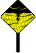

In [27]:
data["hoje"][0]

ModuleNotFoundError: No module named 'numpy.rec'